<a href="https://colab.research.google.com/github/CristianoCoelhoSilva/Python/blob/master/Script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import seaborn
import matplotlib
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso#Loading the dataset
import matplotlib.pyplot as plt
import statsmodels.api as sm
%matplotlib inline

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [10]:
#Arquivo completo
df = pd.read_csv(r"https://raw.githubusercontent.com/CristianoCoelhoSilva/Python/master/Python/covid.csv")

#Removendo as colunas
df.drop(["GENERO","RACA","MES",'ESCOLARIDADE'], axis="columns", inplace=True)
df.drop(["ENTUBADO"], axis="columns", inplace=True)

In [11]:
df.columns

Index(['IDADE', 'FEBRE', 'TOSSE', 'GARGANTA', 'RESPIRAR', 'CABECA', 'PEITO',
       'NAUSEA', 'NARIZ', 'FADIGA', 'OLHOS', 'OLFATO', 'MUSCULAR', 'DIARREIA',
       'DIABETES', 'HIPERTENSAO', 'RESPIRATORIO', 'CORACAO', 'DEPRESSAO',
       'CANCER', 'ESTABELECIMENTO', 'INTERNADO'],
      dtype='object')

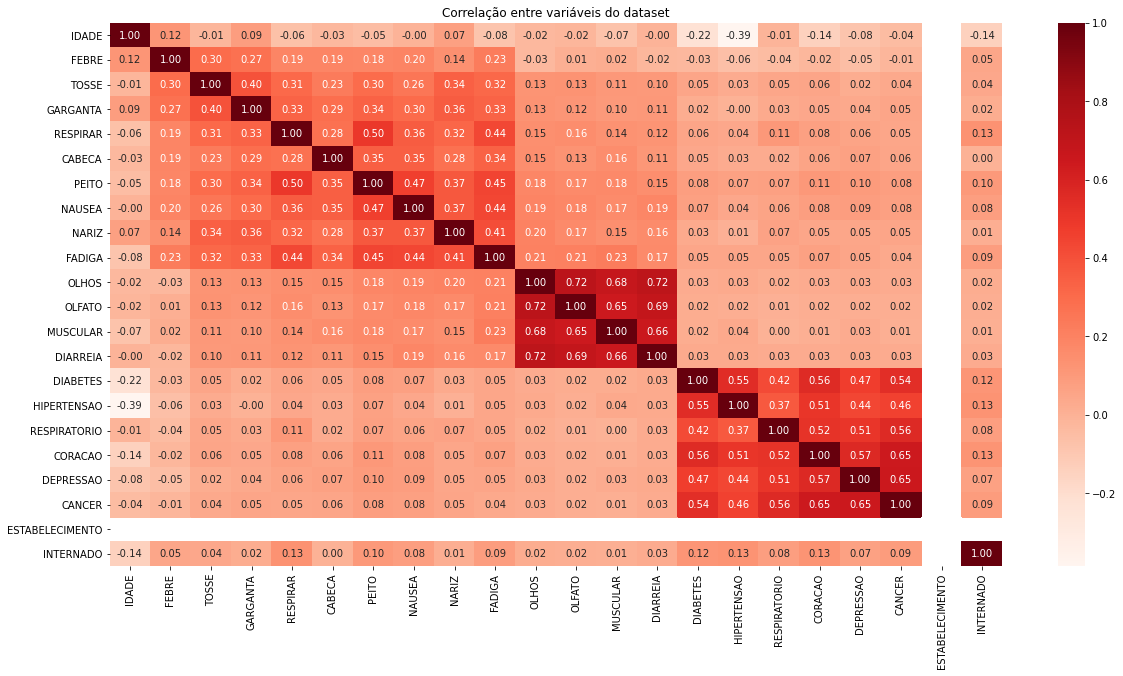

In [12]:
a4_dims = (20, 10)
fig, ax = plt.subplots(figsize=a4_dims)

seaborn.heatmap(df.corr(),
            annot = True,
            fmt = '.2f',
            cmap='Reds')
plt.title('Correlação entre variáveis do dataset')
plt.show()

In [13]:
X = df.drop(['INTERNADO'], axis = "columns")
y = df.INTERNADO

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 13)

X_train

# Cria nosso pipeline para pré-processamento com imputação, dummização e normalização
encoder_imputer_scaled_transformer = make_column_transformer(
    (make_pipeline(
        (KNNImputer(n_neighbors = 3)),
        (StandardScaler())
    ) , make_column_selector(dtype_include = np.number)),
    (make_pipeline(
        SimpleImputer(strategy = 'most_frequent'),
        OneHotEncoder(handle_unknown = 'ignore'),
    ), make_column_selector(dtype_exclude = np.number)),
    remainder = 'passthrough'
)

encoder_imputer_scaled_transformer.fit(X_train)

X_train_processed = encoder_imputer_scaled_transformer.transform(X_train)
X_test_processed = encoder_imputer_scaled_transformer.transform(X_test)

model  = RandomForestClassifier()
model.fit(X_train_processed, y_train)# Mostrando importância de cada feature
model.feature_importances_

array([0.39162612, 0.03139177, 0.03912788, 0.03766563, 0.03594957,
       0.04035359, 0.0320895 , 0.03071409, 0.03587296, 0.02964036,
       0.03330546, 0.03403911, 0.04139945, 0.03842423, 0.02920372,
       0.03019101, 0.02971147, 0.02502502, 0.02298068, 0.01128838,
       0.        ])

Text(0.5, 1.0, 'Importância de cada feature')

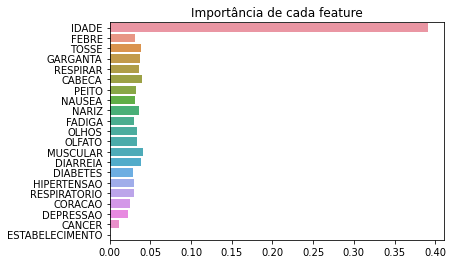

In [14]:
importances = pd.Series(data=model.feature_importances_, index=X.columns)
seaborn.barplot(x=importances, y=importances.index, orient='h').set_title('Importância de cada feature')

In [15]:
#apply SelectKBest class to extract top 10 best features
bestfeatures = SelectKBest(score_func=chi2, k=10)
fit = bestfeatures.fit(X,y)

dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)
#concat two dataframes for better visualization 
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score']  #naming the dataframe columns
print(featureScores.nlargest(10,'Score'))  #print 10 best features

          Specs        Score
0         IDADE  4209.911966
13     DIARREIA    70.771055
15  HIPERTENSAO    54.672826
3      GARGANTA    51.416049
8         NARIZ    49.955685
4      RESPIRAR    47.293066
6         PEITO    46.199088
14     DIABETES    43.325900
7        NAUSEA    42.056019
17      CORACAO    39.585077


In [16]:
reg = LassoCV()
reg.fit(X, y)
print("Best alpha using built-in LassoCV: %f" % reg.alpha_)
print("Best score using built-in LassoCV: %f" %reg.score(X,y))
coef = pd.Series(reg.coef_, index = X.columns)

Best alpha using built-in LassoCV: 0.006613
Best score using built-in LassoCV: 0.039316


Text(0.5, 1.0, 'Feature importance using Lasso Model')

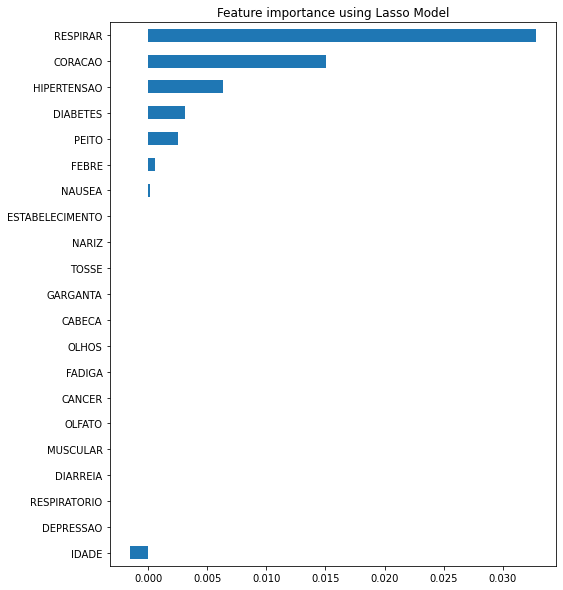

In [17]:
imp_coef = coef.sort_values()
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8.0, 10.0)
imp_coef.plot(kind = "barh")
plt.title("Feature importance using Lasso Model")

## Cross Validation